In [1]:
!git clone https://github.com/Coolgayte/cs3244-stock-forecasting.git /content/cs3244-stock-forecasting.git

Cloning into '/content/cs3244-stock-forecasting.git'...
remote: Enumerating objects: 946, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 946 (delta 0), reused 3 (delta 0), pack-reused 928 (from 2)
Receiving objects: 100% (946/946), 206.36 MiB | 9.39 MiB/s, done.
Resolving deltas: 100% (200/200), done.
Updating files: 100% (489/489), done.


# **Stock Forecast - Baseline XGBoost Model**
## Please run this notebook in Google Colab for smoother configuration
By default, this notebook will save evaluation metrics of the models in a pdf to Google Drive.  
If you wish to tweak the save settings, please go to **Part 5**
### Q&A
**What metrics were included in the final evaluation report?**  
The report consolidated four key performance indicators: Test Mean Squared Error (MSE), Directional Accuracy (%), R-Squared Score (R2), and Mean Absolute Percentage Error (MAPE).

**Where is the final report stored?**  
The "XGBoost_Evaluation_Report" was saved to the Google Drive directory: `/content/drive/MyDrive/CS3244_XGBoost_logs/`.


# 0 Preparing Libraries

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
try:
  import optuna
except ModuleNotFoundError:
  !pip install optuna
  import optuna
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.1 MB/s eta 0:00:00


# 1 Loading Data
Every sector is loaded

In [3]:
model_ready_sectors_partial_path = '/content/cs3244-stock-forecasting.git/data/processed/model_ready_sectors'
sectors = ['banks', 'energy', 'retail', 'shipping', 'tech', 'top_volume']
sector_partial_paths = {}
for sector in sectors:
  sector_partial_paths[sector] = model_ready_sectors_partial_path + '/' + sector

In [4]:
def read_train_val_test_data(sector_id):
  train_path = sector_partial_paths[sector_id] + '/train.csv'
  train_df = pd.read_csv(train_path)
  val_path = sector_partial_paths[sector_id] + '/val.csv'
  val_df = pd.read_csv(val_path)
  test_path = sector_partial_paths[sector_id] + '/test.csv'
  test_df = pd.read_csv(test_path)
  return {
      "train": train_df,
      "val": val_df,
      "test": test_df
  }

In [5]:
sector_data = {}
for sector in sectors:
  sector_data[sector] = read_train_val_test_data(sector)
# Among the 5 sectors, shipping has high volatility
print(sector_data.keys())

dict_keys(['banks', 'energy', 'retail', 'shipping', 'tech', 'top_volume'])


# 2 Adaptive Data Processing
This section dynamically scans the dataset to separate our target variable (`log_return_return_1d`) and temporal marker (`date`) from our dynamically provided technical indicators.

In [6]:
date = ['Date']
ticker = ['ticker']
target = ['target_log_return_1d']
indicator_vars = [
    'rsi_14', 'macd_line', 'macd_hist',
    'ema_50_200_ratio', 'bb_width',
    'log_return',
]

In [7]:
for s in sector_data:
  for t in sector_data[s]:
    sector_data[s][t]['Date'] = pd.to_datetime(sector_data[s][t]['Date'])
    sector_data[s][t] = sector_data[s][t][date + ticker + indicator_vars + target]

In [8]:
sector_data['banks']['test'].columns

Index(['Date', 'ticker', 'rsi_14', 'macd_line', 'macd_hist',
       'ema_50_200_ratio', 'bb_width', 'target_log_return_1d'],
      dtype='object')

## 2.1 Label Encoding
Encode `ticker` column with integers  
`label_encoder.inverse_transform(code)` allows for inverse mapping

In [9]:
from sklearn.preprocessing import LabelEncoder

# 1. Collect all unique tickers across all sectors and splits to ensure a global mapping
all_tickers = set()
for s in sector_data:
    for t in sector_data[s]:
        all_tickers.update(sector_data[s][t]['ticker'].unique())

# 2. Fit the encoder once
label_encoder = LabelEncoder()
label_encoder.fit(list(all_tickers))

# 3. Transform all datasets using the fixed mapping
for s in sector_data:
    for t in sector_data[s]:
        sector_data[s][t]['ticker'] = label_encoder.transform(sector_data[s][t]['ticker'])

print(f"There are {len(label_encoder.classes_)} unique tickers across all sectors.")

Encoded 128 unique tickers across all sectors.


### -- Milestone --   
All data have:  
- date
- 5 indicator variables (unscaled)
- target_log_return_1d as targer var


## 2.2 X and y Isolation
Separating our dynamically identified technical indicators (`X`) from the target log returns (`y`) across all three splits.

In [10]:
sector_data_X_y = {}
for s in sector_data:
  sector_data_X_y[s] = {}
  for t in sector_data[s]:
    sector_data_X_y[s][t] = {}
    sector_data_X_y[s][t]['X'] = sector_data[s][t][ticker + indicator_vars]
    sector_data_X_y[s][t]['y'] = sector_data[s][t][target]

# 3 Bayesian Optimization & Final Model Training
For each sector, perform Optuna hyperparameter optimization, train a final model on combined **train+val** sets, and evaluate performance on the test set using **MSE, Directional Accuracy (DA), R-Squared, and MAPE**.   
Aggregate these metrics and feature importances to generate a consolidated summary table in preparation for cross-category visualizations.

## 3.1 Define Multi-Sector Processing Loop
Create a centralized loop to iterate through all sectors (banks, energy, retail, shipping, tech) to perform hyperparameter optimization, model training, and evaluation.


In [11]:
# Initialize results container
all_sector_results = []

# Iterate through all sectors
for sector_id in sector_data_X_y.keys():
    print(f"\n{'='*20} Processing Sector: {sector_id.upper()} {'='*20}")

    # Extract datasets for current sector
    X_train = sector_data_X_y[sector_id]['train']['X']
    y_train = sector_data_X_y[sector_id]['train']['y']
    X_val = sector_data_X_y[sector_id]['val']['X']
    y_val = sector_data_X_y[sector_id]['val']['y']
    X_test = sector_data_X_y[sector_id]['test']['X']
    y_test = sector_data_X_y[sector_id]['test']['y']

    # Define sector-specific objective function
    def sector_objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
            'max_depth': trial.suggest_int('max_depth', 2, 7),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'random_state': 42,
            'objective': 'reg:squarederror',
            'tree_method': 'hist',
            'n_jobs': -1,
            'enable_categorical': True
        }
        model = xgb.XGBRegressor(**param)
        model.fit(X_train, y_train, verbose=False)
        preds = model.predict(X_val)
        return mean_squared_error(y_val, preds)

    # Run Optuna optimization
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='minimize')
    study.optimize(sector_objective, n_trials=50)
    best_params = study.best_params
    print(f"Best Val MSE for {sector_id}: {study.best_value:.7f}")

    # Aggregate Train, Val Data for final model training
    X_train_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
    y_train_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

    # Final Model Fit & Test Prediction
    final_params = {**best_params, 'enable_categorical': True, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'random_state': 42}
    final_model = xgb.XGBRegressor(**final_params)
    final_model.fit(X_train_full, y_train_full)
    test_preds = final_model.predict(X_test)

    # Calculate Metrics
    # MSE
    test_mse = mean_squared_error(y_test, test_preds)
    # Directional Accuracy
    da = (np.sign(y_test.values.flatten()) == np.sign(test_preds.flatten())).mean() * 100
    # R-Squared
    r2 = r2_score(y_test, test_preds)
    # MAPE (Price Reversion)
    raw_test_df = pd.read_csv(sector_partial_paths[sector_id] + '/test.csv')
    current_closes = raw_test_df['Close'].values
    actual_prices = current_closes * np.exp(y_test.values.flatten())
    pred_prices = current_closes * np.exp(test_preds.flatten())
    mape = np.mean(np.abs((actual_prices - pred_prices) / actual_prices)) * 100

    # Store results
    sector_results = {
        'sector': sector_id,
        'test_mse': test_mse,
        'directional_accuracy': da,
        'r2_score': r2,
        'mape': mape,
        'feature_importance': dict(zip(X_test.columns, final_model.feature_importances_))
    }
    all_sector_results.append(sector_results)
    print(f"Results for {sector_id} saved.\n \
            Test MSE:  {test_mse:.7f},\n \
            DA:        {da:.2f}%,\n \
            R-Squared: {r2:.4f},\n \
            MAPE:      {mape:.2f}%."
    )


print("\nAll sectors processed successfully.")


==================== Processing Sector: BANKS ====================
Best Val MSE for banks: 0.0002503
Results for banks saved.
             Test MSE:  0.0003020,
             DA:        50.88%,
             R-Squared: -0.0034,
             MAPE:      1.14%.

==================== Processing Sector: ENERGY ====================
Best Val MSE for energy: 0.0004898
Results for energy saved.
             Test MSE:  0.0004818,
             DA:        50.06%,
             R-Squared: 0.0008,
             MAPE:      1.45%.

==================== Processing Sector: RETAIL ====================
Best Val MSE for retail: 0.0002501
Results for retail saved.
             Test MSE:  0.0003105,
             DA:        51.86%,
             R-Squared: -0.0029,
             MAPE:      1.15%.

==================== Processing Sector: SHIPPING ====================
Best Val MSE for shipping: 0.0013000
Results for shipping saved.
             Test MSE:  0.0021472,
             DA:        48.44%,
             R-Squ

# 4 Evaluation Metrics & Cross-Sector Visualizations
Generate a comprehensive multi-sector stock forecasting analysis report in PDF format. (To be saved to Google Drive in Part 5)

1.  **Aggregate Metrics**: Consolidate the evaluation results (Test MSE, Directional Accuracy, R-Squared, and MAPE) from the `all_sector_results` list for all sectors (banks, energy, retail, shipping, tech) into a single pandas DataFrame.
2.  **Generate Cross-Sector Visualizations**: Create multi-panel bar charts using `seaborn` to compare the performance of all sectors across the four key metrics. Save these plots as temporary PNG files.
3.  **Generate Feature Importance Plots**: For each sector, generate an individual bar chart showing the relative importance of technical indicators (from the `feature_importance` dictionary) and save them as temporary PNG files.

## 4.1 Aggregate Sector Metrics
Initialize a results container and format the collected metrics (Test MSE, DA, R-Squared, and MAPE) for all sectors into a single pandas DataFrame for easy reporting and plotting.


In [12]:
# 1. Convert the list of dictionaries into a DataFrame
results_df = pd.DataFrame(all_sector_results)

# 2. Select and reorder columns for clarity
## (excluding feature importance dictionaries)
column_order = ['sector', 'test_mse', 'directional_accuracy', 'r2_score', 'mape']
results_df = results_df[column_order]
pd.options.display.float_format = '{:,.6f}'.format # format

print("--- Consolidated Sector Performance Metrics ---")
display(results_df)

# Verify that all 5 sectors are present
print(f"\nTotal sectors aggregated: {len(results_df)}")

--- Consolidated Sector Performance Metrics ---


,sector,test_mse,directional_accuracy,r2_score,mape
0,banks,0.000302,50.878816,-0.003399,1.136401
1,energy,0.000482,50.058027,0.000797,1.447612
2,retail,0.000310,51.861702,-0.002900,1.148805
3,shipping,0.002147,48.442809,0.001133,2.788005
4,tech,0.000315,55.114894,-0.001652,1.087283
5,top_volume,0.000427,51.468085,0.002117,1.248609



Total sectors aggregated: 6


## 4.2 Generate Cross-Sector Visualizations
Create a multi-panel visualization using seaborn to compare the performance of all sectors across our four key metrics. These plots will be saved as temporary images for the PDF report.


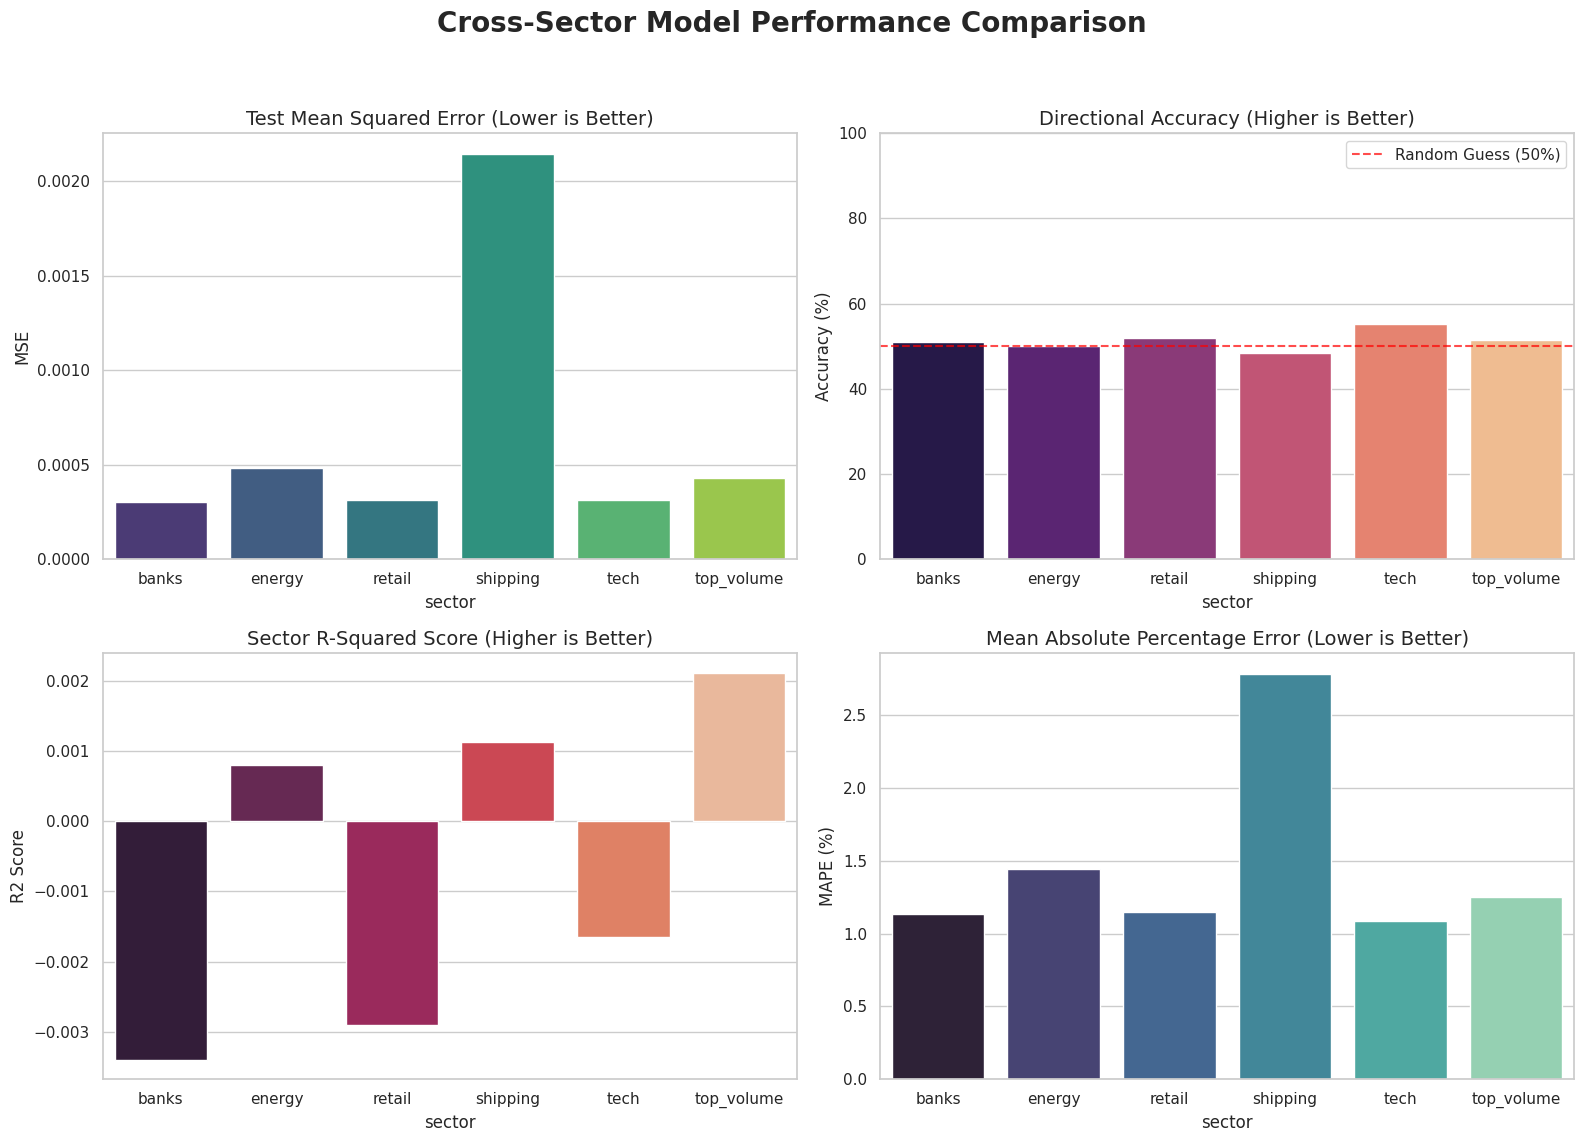

Cross-sector comparison plot saved as 'cross_sector_comparison.png'.


In [13]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cross-Sector Model Performance Comparison', fontsize=20, fontweight='bold')

# 2. Plot Test MSE
sns.barplot(ax=axes[0, 0], x='sector', y='test_mse', data=results_df, palette='viridis', hue='sector', legend=False)
axes[0, 0].set_title('Test Mean Squared Error (Lower is Better)', fontsize=14)
axes[0, 0].set_ylabel('MSE')

# 3. Plot Directional Accuracy
sns.barplot(ax=axes[0, 1], x='sector', y='directional_accuracy', data=results_df, palette='magma', hue='sector', legend=False)
axes[0, 1].axhline(50, color='red', linestyle='--', alpha=0.7, label='Random Guess (50%)')
axes[0, 1].set_title('Directional Accuracy (Higher is Better)', fontsize=14)
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_ylim(0, 100)
axes[0, 1].legend()

# 4. Plot R-Squared
sns.barplot(ax=axes[1, 0], x='sector', y='r2_score', data=results_df, palette='rocket', hue='sector', legend=False)
axes[1, 0].set_title('Sector R-Squared Score (Higher is Better)', fontsize=14)
axes[1, 0].set_ylabel('R2 Score')

# 5. Plot MAPE
sns.barplot(ax=axes[1, 1], x='sector', y='mape', data=results_df, palette='mako', hue='sector', legend=False)
axes[1, 1].set_title('Mean Absolute Percentage Error (Lower is Better)', fontsize=14)
axes[1, 1].set_ylabel('MAPE (%)')

# Adjust layout and save
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('cross_sector_comparison.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

print("Cross-sector comparison plot saved as 'cross_sector_comparison.png'.")

Loop through the `all_sector_results` list to generate and save individual **feature importance bar charts** for each sector (banks, energy, retail, shipping, tech) as temporary PNG files.



In [14]:
# Loop through each sector's results
for result in all_sector_results:
    sector_name = result['sector']
    importance_dict = result['feature_importance']

    # 1. Convert dictionary to DataFrame
    feat_imp_df = pd.DataFrame({
        'Feature': list(importance_dict.keys()),
        'Importance': list(importance_dict.values())
    })

    # 2. Sort by importance
    feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

    # 3. Create the plot
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='Importance',
        y='Feature',
        data=feat_imp_df,
        palette='viridis',
        hue='Feature',
        legend=False
    )

    # 4. Add labels and title
    plt.title(f"Feature Importance: {sector_name.upper()} Sector", fontsize=14)
    plt.xlabel("Gain (Relative Importance)", fontsize=12)
    plt.ylabel("Technical Indicator", fontsize=12)
    plt.tight_layout()

    # 5. Save the plot as a PNG file
    filename = f'feat_imp_{sector_name}.png'
    plt.savefig(filename, bbox_inches='tight')
    plt.close()  # Close to free memory

    print(f"Saved feature importance plot for {sector_name} as '{filename}'.")

Saved feature importance plot for banks as 'feat_imp_banks.png'.
Saved feature importance plot for energy as 'feat_imp_energy.png'.
Saved feature importance plot for retail as 'feat_imp_retail.png'.
Saved feature importance plot for shipping as 'feat_imp_shipping.png'.
Saved feature importance plot for tech as 'feat_imp_tech.png'.
Saved feature importance plot for top_volume as 'feat_imp_top_volume.png'.


# 5 Saving Results as PDF
- All evaluation metrics and feature importance plots generated and saved as local PNG files,
- Assemble the final PDF report using the fpdf2 library.

This involves adding the title, a summary results table from results_df, the cross-sector comparison plot, and each individual sector's feature importance plot.



In [15]:
from google.colab import drive
import os

# Check if drive is already mounted to avoid ValueError
if not os.path.exists('/content/drive/MyDrive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive', force_remount=True)
else:
    print("Google Drive is already mounted.")

Google Drive is already mounted.


## 5.1 Check Google Drive Write Access
Verify and prepare the destination directory on Google Drive for saving the PDF report.


In [16]:
# 1. Define the target directory path
target_dir = '/content/drive/MyDrive/CS3244_XGBoost_logs/'

# 2. Ensure directory exists
if not os.path.exists(target_dir):
    try:
        os.makedirs(target_dir, exist_ok=True)
        print(f"Directory created: {target_dir}")
    except Exception as e:
        print(f"Error creating directory: {e}")
else:
    print(f"Directory already exists: {target_dir}")

# 3. Verify write permissions
dummy_file_path = os.path.join(target_dir, 'permission_test.tmp')
try:
    with open(dummy_file_path, 'w') as f:
        f.write('test')
    os.remove(dummy_file_path)
    print(f"Write access verified for: {target_dir}")
    directory_ready = True
except Exception as e:
    print(f"Write access denied or error occurred: {e}")
    directory_ready = False

if directory_ready:
    print("\n--- Destination directory is ready and writable ---")

Directory already exists: /content/drive/MyDrive/CS3244_XGBoost_logs/
Write access verified for: /content/drive/MyDrive/CS3244_XGBoost_logs/

--- Destination directory is ready and writable ---


## 5.2 Creating & Saving the PDF

In [17]:
try:
  from fpdf import FPDF
  from fpdf.enums import XPos, YPos
except ModuleNotFoundError:
  !pip install fpdf2
  from fpdf import FPDF
  from fpdf.enums import XPos, YPos
try:
  import pytz
except ModuleNotFoundError:
  !pip install pytz
  import pytz
from datetime import datetime
import os

# PDF metadata
timestamp = datetime.now(pytz.timezone('Asia/Singapore')).strftime('%m-%d_%H-%M')
pdf_output_path = f'/content/drive/MyDrive/CS3244_XGBoost_logs/XGBoost_Evaluation_Report_{timestamp}.pdf'

class XGBoostReport(FPDF):
    def header(self):
        self.set_font('Helvetica', 'B', 15)
        self.cell(0, 10, 'Multi-Sector XGBoost Forecasting Analysis Report', align='C', ln=1)
        self.set_font('Helvetica', 'I', 10)
        self.cell(0, 10, f'Generated: {timestamp} (SGT)', align='C', ln=1)
        self.ln(10)

    def footer(self):
        self.set_y(-15)
        self.set_font('Helvetica', 'I', 8)
        self.cell(0, 10, f'Page {self.page_no()}', align='C')

# Initialize PDF
pdf = XGBoostReport()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()

# Add Sector List and Variables' Descriptions
pdf.set_font('Helvetica', '', 10)
pdf.multi_cell(0, 5, f"""This report evaluates XGBoost models across multiple financial categories.
The analyzed categories include:\n{', '.join([s.capitalize() for s in sectors])}.

For each sector, the models utilized the following technical indicators as features:\n{',\n'.join(indicator_vars)}.
The target variable for forecasting is:\n{target[0]}.
""")
pdf.ln(10)

# Add Summary Results Table
pdf.set_font('Helvetica', 'B', 12)
pdf.cell(0, 10, 'I. Consolidated Category Metrics', ln=1)
pdf.ln(2)

# Table Header
pdf.set_font('Helvetica', 'B', 10)
columns = ['Sector', 'Test MSE', 'DA (%)', 'R2 Score', 'MAPE (%)']
col_widths = [30, 40, 40, 40, 40]
for i, col in enumerate(columns):
    pdf.cell(col_widths[i], 10, col, border=1, align='C')
pdf.ln()

# Table Rows
pdf.set_font('Helvetica', '', 10)
for index, row in results_df.iterrows():
    pdf.cell(col_widths[0], 10, str(row['sector']).capitalize(), border=1, align='C')
    pdf.cell(col_widths[1], 10, f"{row['test_mse']:.6f}", border=1, align='C')
    pdf.cell(col_widths[2], 10, f"{row['directional_accuracy']:.2f}%", border=1, align='C')
    pdf.cell(col_widths[3], 10, f"{row['r2_score']:.4f}", border=1, align='C')
    pdf.cell(col_widths[4], 10, f"{row['mape']:.2f}%", border=1, align='C')
    pdf.ln()

pdf.ln(10)

# Add Cross-Sector Comparison Plots
pdf.set_font('Helvetica', 'B', 12)
pdf.cell(0, 10, 'II. Cross-Category Performance Comparison', ln=1)
pdf.image('cross_sector_comparison.png', x=10, y=None, w=190)
pdf.add_page()

# Add Individual Feature Importance Plots
pdf.set_font('Helvetica', 'B', 12)
pdf.cell(0, 10, 'III. Category-Specific Feature Importances', ln=1)
pdf.ln(5)

for sector_id in sectors:
    img_path = f'feat_imp_{sector_id}.png'
    if os.path.exists(img_path):
        pdf.set_font('Helvetica', 'B', 11)
        pdf.cell(0, 10, f'Category: {sector_id.capitalize()}', ln=1)
        pdf.image(img_path, x=15, y=None, w=170)
        pdf.ln(5)

# Save PDF and Cleanup
os.makedirs(os.path.dirname(pdf_output_path), exist_ok=True)
pdf.output(pdf_output_path)

temp_files = ['cross_sector_comparison.png'] + [f'feat_imp_{s}.png' for s in sectors]
for f in temp_files:
    if os.path.exists(f):
        os.remove(f)

print(f'\n Success! Report saved to: {pdf_output_path}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 12.8 MB/s eta 0:00:00


/tmp/ipykernel_1585/1047334899.py:24: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 10, 'Multi-Sector XGBoost Forecasting Analysis Report', align='C', ln=1)
/tmp/ipykernel_1585/1047334899.py:27: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 10, f'Generated: {timestamp} (SGT)', align='C', ln=1)
/tmp/ipykernel_1585/1047334899.py:53: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, 'I. Consolidated Category Metrics', ln=1)
/tmp/ipykernel_1585/1047334899.py:78: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, 'II. Cross-Category Performance Comparison', ln=1)
/tmp/ipykernel_1585/1047334899.py:84: DeprecationWarning: The para


✅ Success! Comprehensive report saved to: /content/drive/MyDrive/CS3244_XGBoost_logs/XGBoost_Evaluation_Report_04-12_20-32.pdf
